In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [2]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


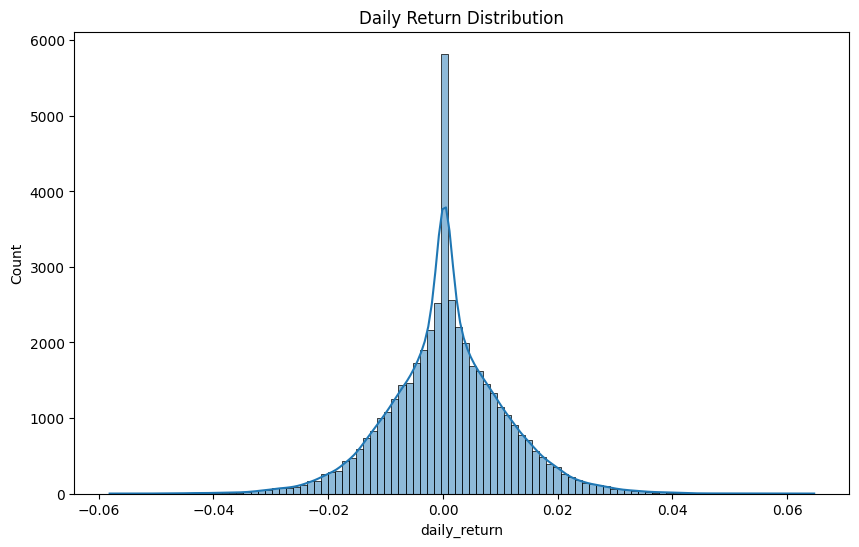

In [3]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()

In [4]:
def calculate_cagr(start_nav,end_nav,years):

    return ((end_nav/start_nav)**(1/years)-1)*100
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
    ) / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_pct"
    ]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [5]:
rf = 0.065

sharpe_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = (
        returns.mean()*252
    )

    annual_vol = (
        returns.std()*np.sqrt(252)
    )

    sharpe = (
        annual_return-rf
    ) / annual_vol

    sharpe_list.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [6]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()*252
    )

    sortino = (
        annual_return-rf
    ) / downside_std

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [8]:
print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [9]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [10]:
print(benchmark["index_name"].unique())
benchmark["index_name"].value_counts()

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [12]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [13]:
alpha_beta = []

nifty = benchmark[
    benchmark["index_name"]=="NIFTY100"
]

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"]==fund
    ]

    merged = pd.merge(
        fund_df,
        nifty,
        on="date"
    )

    merged["benchmark_return"] = (
        merged["close_value"]
        .pct_change()
    )

    merged = merged.dropna()
    if len(merged) < 2:
        continue

    beta,alpha,r,p,std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = alpha*252

    alpha_beta.append(
        [fund,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [14]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"]==fund
    ]

    running_max = (
        df["nav"].cummax()
    )

    drawdown = (
        df["nav"]/running_max
    ) - 1

    max_dd = drawdown.min()

    drawdowns.append(
        [fund,max_dd]
    )

dd_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [15]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(dd_df)
)

scorecard["score"] = (
      scorecard["cagr_pct"].rank(pct=True)*30
    + scorecard["sharpe_ratio"].rank(pct=True)*25
    + scorecard["alpha"].rank(pct=True)*20
    + scorecard["max_drawdown"].rank(
        ascending=False,
        pct=True
      )*10
)

scorecard["score"] = (
    scorecard["score"]
    / scorecard["score"].max()
    *100
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [16]:
top5_funds = scorecard.sort_values(
    "score",
    ascending=False
).head(5)["amfi_code"]

top5_funds

25    120505
36    148569
21    119598
39    149324
30    120843
Name: amfi_code, dtype: int64

In [17]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])

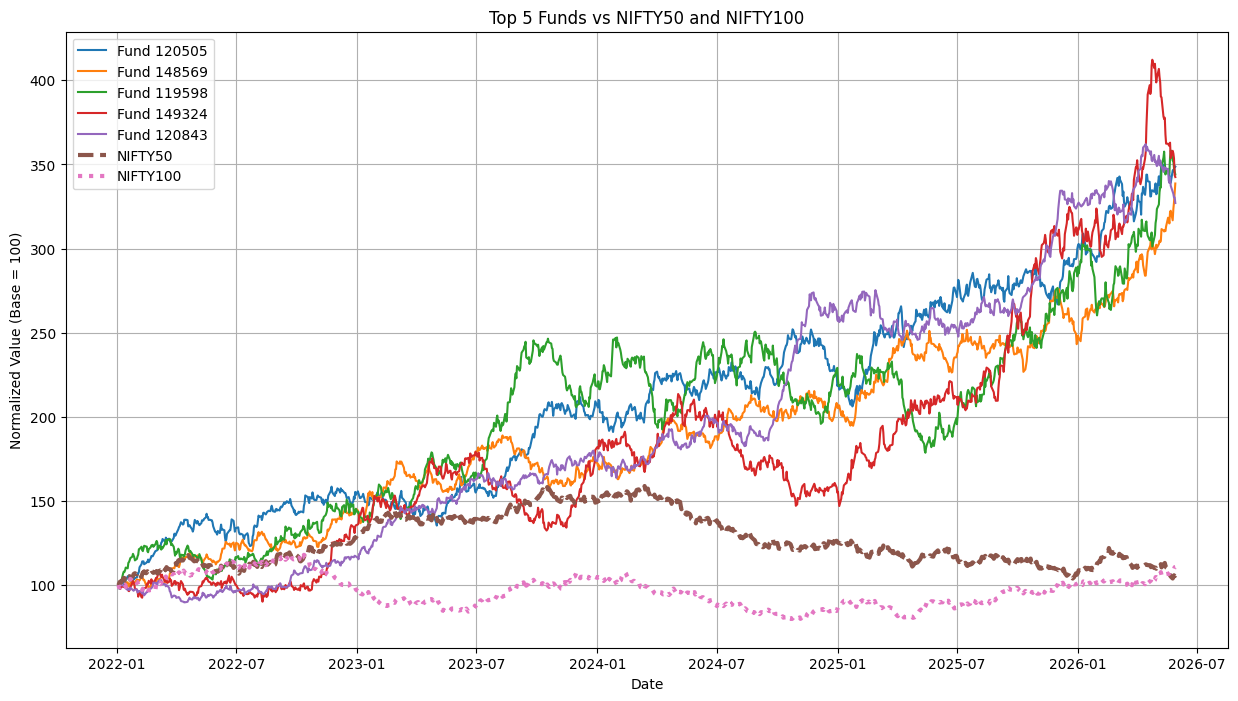

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

# Top 5 funds
for fund in top5_funds:

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    # Normalize to 100
    fund_data["normalized_nav"] = (
        fund_data["nav"] /
        fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        fund_data["normalized_nav"],
        label=f"Fund {fund}"
    )

# NIFTY50
nifty50 = nifty50.sort_values("date")
nifty50["normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

# NIFTY100
nifty100 = nifty100.sort_values("date")
nifty100["normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    linestyle=":",
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 and NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
fund = top5_funds.iloc[0]

fund_data = nav[
    nav["amfi_code"] == fund
].copy()

fund_data = fund_data.sort_values("date")

merged = pd.merge(
    fund_data,
    nifty100,
    on="date"
)

merged["benchmark_return"] = (
    merged["close_value"]
    .pct_change()
)

merged = merged.dropna()

tracking_error = (
    (merged["daily_return"] -
     merged["benchmark_return"])
    .std()
    * np.sqrt(252)
)

print(
    f"Tracking Error: {tracking_error:.4f}"
)

Tracking Error: 0.2320
